In [1]:
from src.runner import preprocess
preprocess()

Processing Center for Advanced Life Cycle Engineering cells: 100%|██████████| 7/7 [00:01<00:00,  3.81it/s]


0 processed, 7 skipped



Processing Hawaii Natural Energy Institute cells: 100%|██████████| 15/15 [00:04<00:00,  3.46it/s]


0 processed, 15 skipped



Processing Oxford cells: 100%|██████████| 8/8 [00:00<00:00, 8447.74it/s]


...

0 processed, 10 skipped



Processing Cell Report Physical Science cells: 100%|██████████| 10/10 [00:00<00:00, 14899.84it/s]


0 processed, 10 skipped



Processing Cell Report Physical Science cells: 100%|██████████| 40/40 [00:00<00:00, 29238.79it/s]

0 processed, 40 skipped



In [2]:
# ===== SET HYPERPARAMETERS =======
num_epochs = 3
window_size = 20
window_skip = 1
index_tuple = (1, 2, 3) # Temp, CO, H2, and maybe CO2

In [4]:
from src.data.train_test_split import get_divided_train_test
import json 
train_cells, test_cells = get_divided_train_test(configfile='healthygas')

with open("results/trained_models/healthy_gasWtrims_train_cells.json", "w") as file:
    json.dump(train_cells, file)
with open("results/trained_models/healthy_gasWtrims_test_cells.json", "w") as file:
    json.dump(test_cells, file)

Checking attributes: 100%|██████████| 485/485 [00:00<00:00, 1560.29it/s]


In [6]:
# ===== INITIALIZE DATALOADERS =======
from src.data import get_divided_loaders, get_divided_loaders_from

healthy_train_loader, healthy_test_loader = get_divided_loaders_from(
    filelist_train = "results/trained_models/healthy_gasWtrims_train_cells.json",
    filelist_test = "results/trained_models/healthy_gasWtrims_test_cells.json",
    window_size=window_size,
    window_skip=window_skip,
    index_tuple=index_tuple
)
_, unhealthy_test_loader = get_divided_loaders(test_size=1.0, window_size=window_size, window_skip=window_skip, configfile='unhealthygas', index_tuple=index_tuple)

Checking attributes: 100%|██████████| 485/485 [00:00<00:00, 4062.70it/s]


In [7]:
# ===== SET HYPERPARAMETERS =======
num_epochs = 3
window_size = 20
window_skip = 1
index_tuple = (1, 2, 3)

from src.data import get_divided_loaders

# healthy_train_loader, healthy_test_loader = get_divided_loaders(test_size=0.2, window_size=window_size, window_skip=window_skip, configfile='healthygas', index_tuple=index_tuple)
# _, unhealthy_test_loader = get_divided_loaders(test_size=1.0, window_size=window_size, window_skip=window_skip, configfile='unhealthygas', index_tuple=index_tuple)

# ===== INITIALIZE TRANSFORMER AUTOENCODER =======
from src.training import *
from src.models import TransformerAutoencoder
import pickle

DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Using device:", DEVICE)

idx_str = ''.join(str(i) for i in index_tuple)
model_filename = f"results/trained_models/GASwTRIMS-{num_epochs}epoch_{window_size}window_{window_skip}step_{idx_str}params.pkl"
print("Model:", model_filename)

retrain = True # NOTE: THIS DETERMINES WHETHER YOU LOAD AN EXISTING MODEL OR TRAIN & SAVE A NEW ONE
if retrain:
    transformer_model = TransformerAutoencoder(
        input_dim=len(index_tuple),     # number of features per timestep
        model_dim=64,                   # hidden embedding dimension
        num_heads=4,                    # parallel attention heads
        num_layers=2                    # stacked encoder/decoder layers
    )

    # took 9m 13s to train 1 epoch with 80% of healthy data files
    transformer_model.to(DEVICE)
    for epoch in range(1,num_epochs+1):
        print(f"Epoch {epoch}/{num_epochs}")
        train_loss = train_epoch(transformer_model, healthy_train_loader, DEVICE)
        print(f" Train loss: {train_loss:.6f}")

    with open(model_filename, 'wb') as file:
        pickle.dump(transformer_model, file)

else:
    transformer_model = TransformerAutoencoder.load(model_filename)

Using device: mps
Model: results/trained_models/GASwTRIMS-3epoch_20window_1step_123params.pkl
Epoch 1/3


/Users/Hanita/Projects/Carleton-Lab/thermal-runaway/src/models/transformer_autoencoder.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
Train: 100%|██████████| 493/493 [00:36<00:00, 13.36it/s, train_loss=56.9]


 Train loss: 56.562040
Epoch 2/3


Train: 100%|██████████| 493/493 [00:32<00:00, 14.97it/s, train_loss=4.13]


 Train loss: 4.112463
Epoch 3/3


Train: 100%|██████████| 493/493 [00:33<00:00, 14.93it/s, train_loss=1.54]

 Train loss: 1.531666


In [13]:
import json 

with open('results/trained_models/healthy_gasWtrims_test_cells.json', 'r') as f:
    healthy_test_filenames = json.load(f)
healthy_test_filenames

['data/preprocessed/synthetic_ThermalRunaway_Overheat_6_Normal_trimmed.pkl',
 'data/preprocessed/Synth_022_BeforeTest3.pkl',
 'data/preprocessed/Synth_057_BeforeTest6.pkl',
 'data/preprocessed/synthetic_ThermalRunaway_Overcharge_10_Normal_trimmed.pkl',
 'data/preprocessed/synthetic_Figure3a_synthetic_runs_4_Normal_trimmed.pkl',
 'data/preprocessed/Synth_023_BeforeTest3.pkl',
 'data/preprocessed/Synth_004_BeforeTest1.pkl',
 'data/preprocessed/Synth_027_BeforeTest3.pkl']

In [17]:
_, unhealthy_test_filenames = get_divided_train_test(1.0, 'unhealthygas')
unhealthy_test_filenames

Checking attributes: 100%|██████████| 485/485 [00:00<00:00, 4150.80it/s]


['data/preprocessed/synth_028__source_Trim5.pkl',
 'data/preprocessed/synth_001__source_Trim2.pkl',
 'data/preprocessed/synth_018__source_Trim3.pkl',
 'data/preprocessed/synth_004__source_Trim2.pkl',
 'data/preprocessed/synth_029__source_Trim5.pkl',
 'data/preprocessed/synth_030__source_Trim5.pkl',
 'data/preprocessed/synth_019__source_Trim3.pkl',
 'data/preprocessed/synth_005__source_Trim2.pkl',
 'data/preprocessed/synthetic_ThermalRunaway_Overcharge_9.pkl',
 'data/preprocessed/synthetic_ThermalRunaway_Overcharge_8.pkl',
 'data/preprocessed/synthetic_ThermalRunaway_Overheat_1.pkl',
 'data/preprocessed/synth_003__source_Trim2.pkl',
 'data/preprocessed/synthetic_ThermalRunaway_Overheat_3.pkl',
 'data/preprocessed/synth_006__source_Trim2.pkl',
 'data/preprocessed/synthetic_ThermalRunaway_Overheat_2.pkl',
 'data/preprocessed/synthetic_ThermalRunaway_Overheat_6.pkl',
 'data/preprocessed/synthetic_ThermalRunaway_Overheat_7.pkl',
 'data/preprocessed/synth_002__source_Trim2.pkl',
 'data/prepr

In [17]:
import os
crps_filenames = []
for filename in os.listdir('data/preprocessed'):
    if '_Overcharge_' in filename or '_Overheat_' in filename:
        crps_filenames += ['data/preprocessed/' + filename]

crps_filenames = sorted(crps_filenames)
crps_filenames

healthy_crps_filenames = []
for filename in os.listdir('data/raw/crps/healthy_crps'):
    filename = filename.split('.')[0]
    healthy_crps_filenames += ['data/preprocessed/' + filename + '.pkl']

crps_filenames, healthy_crps_filenames

(['data/preprocessed/synthetic_ThermalRunaway_Overcharge_1.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_10.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_10_Normal_trimmed.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_1_Normal_trimmed.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_2.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_2_Normal_trimmed.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_3.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_3_Normal_trimmed.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_4.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_4_Normal_trimmed.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_5.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_5_Normal_trimmed.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_6.pkl',
  'data/preprocessed/synthetic_ThermalRunaway_Overcharge_6_Norm

In [12]:
import json
from src.validation import *
from src.data.train_test_split import *

def store_gas_reconstruction_errors(window_size, window_skip, healthy=True):
    if healthy:
        with open('results/trained_models/healthy_gasWtrims_test_cells.json', 'r') as f:
            filenames = json.load(f)
        name = 'healthyGASwTRIMS_test'
    
    else:
        _, filenames = get_divided_train_test(1.0, 'unhealthygas')
        name = 'unhealthyGASwTRIMS'

    store_reconstruction_errors(
        model_filename=model_filename,
        filenames=filenames, 
        window_size=window_size,
        window_skip=window_skip,
        index_tuple=index_tuple,
        save_to=f"results/reconstruction_errs/{name}_w{window_size}.json"
    )

In [14]:
from src.validation import * 
window_size = 10
window_skip = 1


store_reconstruction_errors(
    model_filename=model_filename,
    filenames=healthy_test_filenames, # H
    window_size=window_size,
    window_skip=window_skip,
    index_tuple=index_tuple,
    save_to=f"results/reconstruction_errs/healthyGASwTRIMS_w{window_size}.json" # H
)

Reconstructing files: 100%|██████████| 8/8 [02:04<00:00, 15.61s/it]

Saved to results/reconstruction_errs/healthyGASwTRIMS_w10.json


{'info': {'model': 'results/trained_models/GASwTRIMS-3epoch_20window_1step_123params.pkl',
  'window_size': 10,
  'window_skip': 1,
  'batch_size': 64,
  'num_workers': 4,
  'index_tuple': (1, 2, 3)},
 'data': {'data/preprocessed/synthetic_ThermalRunaway_Overheat_6_Normal_trimmed.pkl': [0.23411060869693756,
   0.26640984416007996,
   0.3140782117843628,
   0.32681092619895935,
   0.29692113399505615,
   0.25995153188705444,
   0.264413446187973,
   0.2926829755306244,
   0.2805240750312805,
   0.28008848428726196,
   0.26755431294441223,
   0.2517033815383911,
   0.23578402400016785,
   0.21782979369163513,
   0.19309145212173462,
   0.1702689677476883,
   0.16419649124145508,
   0.1593453586101532,
   0.13995838165283203,
   0.1282394677400589,
   0.11968012154102325,
   0.11848346143960953,
   0.1245720386505127,
   0.13369785249233246,
   0.14621397852897644,
   0.18388131260871887,
   0.2325078397989273,
   0.27726617455482483,
   0.30288001894950867,
   0.34146416187286377,
   0.3

In [18]:
store_reconstruction_errors(
    model_filename=model_filename,
    filenames=unhealthy_test_filenames, # H
    window_size=window_size,
    window_skip=window_skip,
    index_tuple=index_tuple,
    save_to=f"results/reconstruction_errs/unhealthyGASwTRIMS_w{window_size}.json" # H
)

Reconstructing files: 100%|██████████| 53/53 [32:18<00:00, 36.58s/it] 

Saved to results/reconstruction_errs/unhealthyGASwTRIMS_w10.json


{'info': {'model': 'results/trained_models/GASwTRIMS-3epoch_20window_1step_123params.pkl',
  'window_size': 10,
  'window_skip': 1,
  'batch_size': 64,
  'num_workers': 4,
  'index_tuple': (1, 2, 3)},
 'data': {'data/preprocessed/synth_028__source_Trim5.pkl': [207452.859375,
   207896.03125,
   208812.171875,
   212034.03125,
   219089.140625,
   230349.21875,
   245663.265625,
   263161.1875,
   279559.9375,
   293107.03125,
   303957.34375,
   312617.8125,
   319649.9375,
   323599.3125,
   323200.09375,
   318019.46875,
   308719.96875,
   297221.6875,
   286622.03125,
   278631.71875,
   273226.96875,
   269584.4375,
   266700.25,
   264397.15625,
   262106.4375,
   260143.40625,
   258237.34375,
   256269.828125,
   254274.03125,
   252511.421875,
   250712.703125,
   248912.640625,
   247432.90625,
   246072.046875,
   245031.953125,
   243996.109375,
   243150.03125,
   242174.5625,
   241396.15625,
   240700.25,
   240231.453125,
   239961.03125,
   239809.921875,
   239616.656

In [15]:
import json 
with open('results/reconstruction_errs/healthyGASwTRIMS_w10.json', 'r') as file:
    healthy_trims_reconstruction = json.load(file)
data = healthy_trims_reconstruction['data']

maximums = []
for filename in data:
    print(f"{filename}: {max(data[filename])}")
    maximums += [max(data[filename])]

data/preprocessed/synthetic_ThermalRunaway_Overheat_6_Normal_trimmed.pkl: 0.6078166365623474
data/preprocessed/Synth_022_BeforeTest3.pkl: 4.1615519523620605
data/preprocessed/Synth_057_BeforeTest6.pkl: 16.322168350219727
data/preprocessed/synthetic_ThermalRunaway_Overcharge_10_Normal_trimmed.pkl: 7.32655668258667
data/preprocessed/synthetic_Figure3a_synthetic_runs_4_Normal_trimmed.pkl: 0.694529116153717
data/preprocessed/Synth_023_BeforeTest3.pkl: 4.511026382446289
data/preprocessed/Synth_004_BeforeTest1.pkl: 0.6139289736747742
data/preprocessed/Synth_027_BeforeTest3.pkl: 3.938894033432007


In [19]:
import json 
with open('results/reconstruction_errs/unhealthyGASwTRIMS_w10.json', 'r') as file:
    unhealthy_reconstruction = json.load(file)
data = unhealthy_reconstruction['data']

maximums = []
for filename in data:
    print(f"{filename}: {max(data[filename])}")
    maximums += [max(data[filename])]

data/preprocessed/synth_028__source_Trim5.pkl: 323599.3125
data/preprocessed/synth_001__source_Trim2.pkl: 105719.3671875
data/preprocessed/synth_018__source_Trim3.pkl: 12055.49609375
data/preprocessed/synth_004__source_Trim2.pkl: 108287.203125
data/preprocessed/synth_029__source_Trim5.pkl: 160772.046875
data/preprocessed/synth_030__source_Trim5.pkl: 288211.46875
data/preprocessed/synth_019__source_Trim3.pkl: 24437.423828125
data/preprocessed/synth_005__source_Trim2.pkl: 87831.75
data/preprocessed/synthetic_ThermalRunaway_Overcharge_9.pkl: 151106.390625
data/preprocessed/synthetic_ThermalRunaway_Overcharge_8.pkl: 446262.40625
data/preprocessed/synthetic_ThermalRunaway_Overheat_1.pkl: 29182202.0
data/preprocessed/synth_003__source_Trim2.pkl: 67354.2421875
data/preprocessed/synthetic_ThermalRunaway_Overheat_3.pkl: 104544112.0
data/preprocessed/synth_006__source_Trim2.pkl: 49453.8046875
data/preprocessed/synthetic_ThermalRunaway_Overheat_2.pkl: 41782100.0
data/preprocessed/synthetic_Therma

In [20]:
sorted(maximums)

[9059.4111328125,
 12055.49609375,
 12435.0244140625,
 13124.0087890625,
 14494.58203125,
 15750.5556640625,
 15774.671875,
 17649.220703125,
 19451.0625,
 19692.7578125,
 24437.423828125,
 49453.8046875,
 50190.2265625,
 53725.20703125,
 67354.2421875,
 78335.1015625,
 87831.75,
 88636.0078125,
 90306.875,
 105719.3671875,
 108287.203125,
 109521.3203125,
 116573.0546875,
 147568.421875,
 151106.390625,
 155688.25,
 156268.65625,
 160772.046875,
 180039.578125,
 201231.15625,
 223313.90625,
 231742.0,
 259798.3125,
 281524.0,
 288211.46875,
 288773.1875,
 299118.09375,
 313522.84375,
 323599.3125,
 364227.875,
 375351.46875,
 446262.40625,
 509549.03125,
 24410700.0,
 29182202.0,
 37910676.0,
 41782100.0,
 42071656.0,
 60089548.0,
 63918276.0,
 87674792.0,
 90998944.0,
 104544112.0]

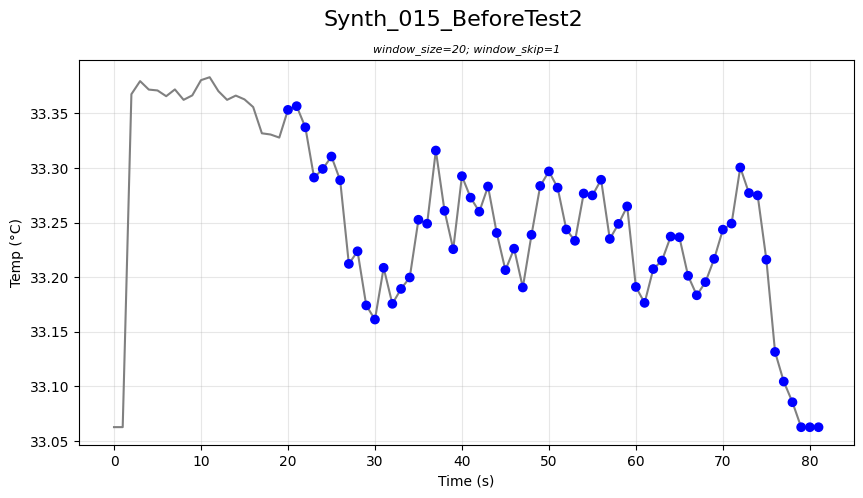

In [23]:
from src.validation import *
filename = "data/preprocessed/Synth_015_BeforeTest2.pkl"

Synth_015_BeforeTest2_evals = evaluate_and_plot(
    filename,
    transformer_model,
    window_size=window_size,
    window_skip=window_skip,
    threshold=200,
    index_tuple=index_tuple
)

In [25]:
healthy_test_errors = get_reconstruction_errors(transformer_model, healthy_test_loader, 'mps')

In [26]:
max(healthy_test_errors)

110.91954803466797

In [27]:
unhealthy_test_errors = get_reconstruction_errors(transformer_model, unhealthy_test_loader, 'mps')

In [43]:
import statistics

print(f"Gas data reconstruction errors on test sets:")
print(f"\t model = {model_filename}")
print(f"-------------------------------")
print(f"\t | HEALTHY | UNHEALTHY")
print(f"-------------------------------")
print(f"MAX:\t | {max(healthy_test_errors):.2f}  | {max(unhealthy_test_errors):.2f}")

print(f"MEDIAN:\t | {statistics.median(healthy_test_errors):.2f}   | {statistics.median(unhealthy_test_errors):.2f}")

print(f"MIN:\t | {min(healthy_test_errors):.2f}   | {min(unhealthy_test_errors):.2f}")

print(f"MEAN:\t | {sum(healthy_test_errors)/len(healthy_test_errors):.2f}   | {sum(unhealthy_test_errors)/len(unhealthy_test_errors):.2f}")


Gas data reconstruction errors on test sets:
	 model = results/trained_models/GAS-3epoch_20window_1step_123params.pkl
-------------------------------
	 | HEALTHY | UNHEALTHY
-------------------------------
MAX:	 | 110.92  | 346333.47
MEDIAN:	 | 46.87   | 1889.44
MIN:	 | 26.64   | 131.32
MEAN:	 | 50.46   | 55421.62


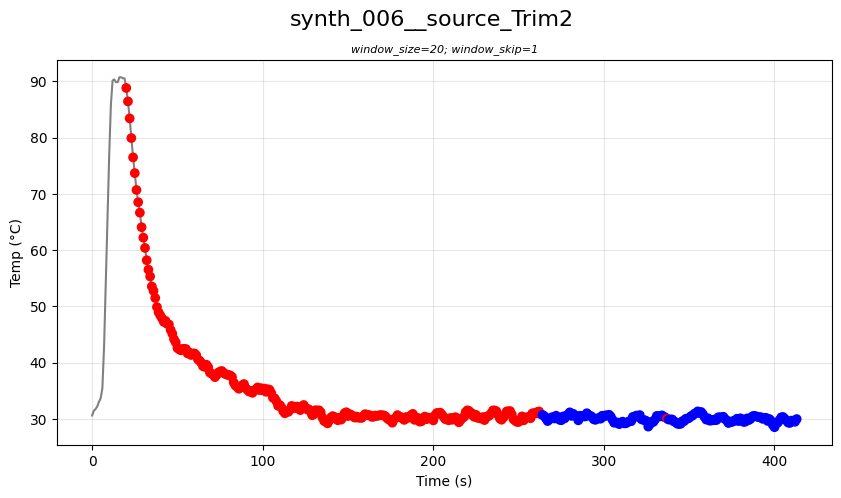

In [24]:
from src.validation import *
filename = "data/preprocessed/synth_006__source_Trim2.pkl"

synth_006__source_Trim2_evals = evaluate_and_plot(
    filename,
    transformer_model,
    window_size=window_size,
    window_skip=window_skip,
    threshold=200,
    index_tuple=index_tuple
)

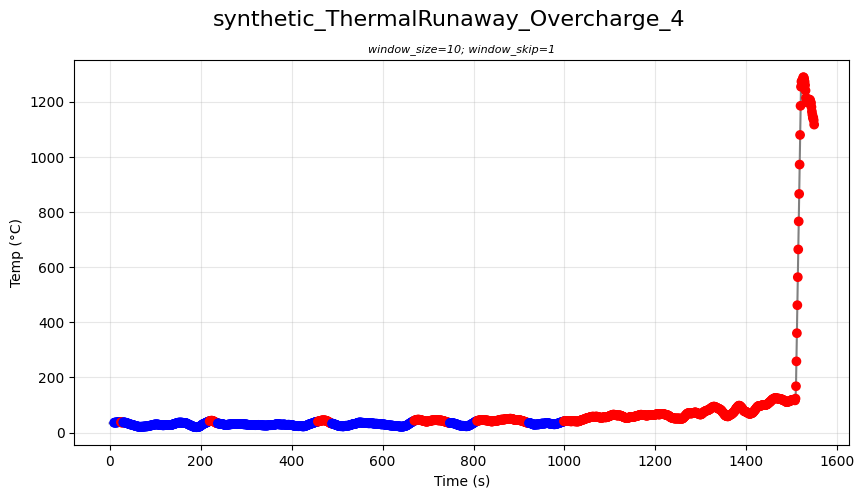

In [9]:
from src.validation import *
filename = "data/preprocessed/synthetic_ThermalRunaway_Overcharge_4.pkl"

overcharge_evals = evaluate_and_plot(
    filename,
    transformer_model,
    window_size=10,
    window_skip=1,
    threshold=200,
    index_tuple=index_tuple
)

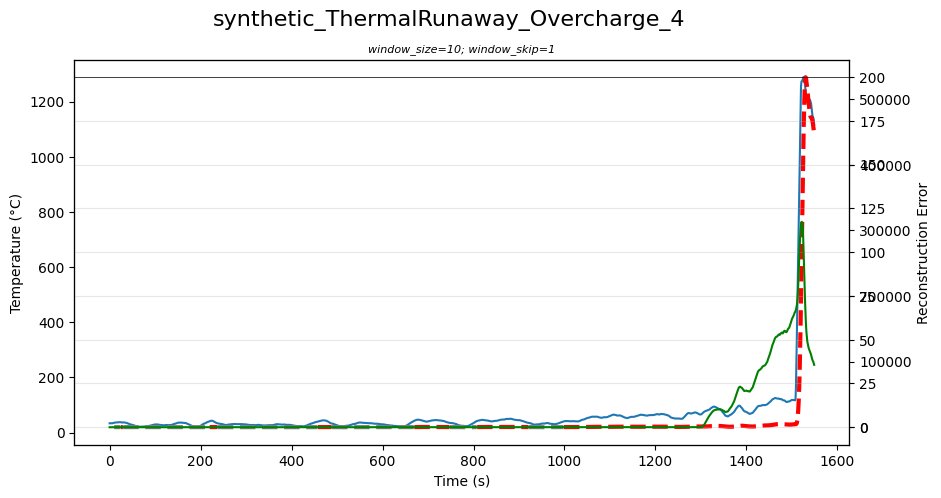

In [12]:
import numpy as np
def plot_errs_on_tempgas(filename, errors, window_size=20, window_skip=1, sampling_rate=1, figsize=(10,5), xlim=None, templim=None, errlim=None, **kwargs):
    """
    Plots the temperature data in the given file with dots indicating whether the data was classified as healthy
    or unhealthy at various timesteps.
    """
    # Get temperature data
    bd = BatteryData.load(filename)
    temps = bd.timeseries_data[0].to_dict()['temperature_in_C']
    temps = np.array(list(temps))
    y = temps[~np.isnan(temps)]
    x = np.arange(len(y)) / sampling_rate

    # Plot the line
    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.plot(x, y, label='Temp')
    ax1.set_ylabel("Temperature (°C)")
    ax1.set_xlabel("Time (s)")

    # Overlay colored dots
    i = np.arange(len(errors))
    idx = i * window_skip + window_size
    idx = idx[:len(x)-window_size]

    
    threshold = 200
    # plt.fill_between(x, 200, 2000, alpha=0.3, color='pink')

    ax2 = ax1.twinx()
    # ax2.plot(x[idx], errors, label="Err", color='red', linestyle='--')
    ax2.set_ylabel("Reconstruction Error")
    errors = np.array(errors)

    below = np.ma.masked_where(errors > threshold, errors)
    above = np.ma.masked_where(errors <= threshold, errors)

    ax2.plot(x[idx], below, color='grey', linestyle='--', linewidth=3)
    ax2.plot(x[idx], above, color='red', linestyle='--', linewidth=3)

    # Plot gas
    h2 = bd.timeseries_data[0].to_dict()['h2_ppmo']
    h2 = np.array(list(h2))
    ax3 = ax1.twinx()
    ax3.plot(x, h2, label='H2', color='green')



    if xlim is not None: plt.xlim(xlim)
    if templim is not None: ax1.set_ylim(0, templim)
    if errlim is not None: ax2.set_ylim(0, errlim)

    plt.axhline(
        y=200,
        color='black',
        linewidth=0.5
    )

    # Make it nice
    plt.suptitle(f"{filename.split('/')[-1].split('.')[0]}", fontsize=16)
    plt.title(f"window_size={window_size}; window_skip={window_skip}", fontdict=SUBTITLE_FONT)
    plt.grid(alpha=0.3)


plot_errs_on_tempgas(
    filename, 
    crps_reconstruction['data'][filename],
    10
)